# Classification on MERFISH dataset

## Load libraries

In [1]:
# Data librarie
import pandas as pd
import anndata as ad
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score, 
                             classification_report,  ConfusionMatrixDisplay,
                             top_k_accuracy_score)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

# Model persistence (saving trained models for later reuse)
import joblib


## Load data

In [2]:
source = "ec_obj_imputed_log2.h5ad"
ec_data = ad.read_h5ad(source)
print(ec_data)

cell_metadata = ec_data.obs
cell_metadata.head()

AnnData object with n_obs × n_vars = 48615 × 8460
    obs: 'brain_section_label', 'class', 'subclass', 'supertype', 'structure', 'substructure', 'x_ccf', 'y_ccf', 'z_ccf'
    var: 'gene_symbol'


,brain_section_label,class,subclass,supertype,structure,substructure,x_ccf,y_ccf,z_ccf
cell_label,,,,,,,,,
1018093344100490327-3,C57BL6J-638850.19,03 OB-CR Glut,036 HPF CR Glut,0135 HPF CR Glut_1,ENTm,ENTm1,10187.352431,3058.025140,8767.202589
1018093343102220029,C57BL6J-638850.24,03 OB-CR Glut,036 HPF CR Glut,0135 HPF CR Glut_1,ENTm,ENTm2,9552.388366,5703.533695,2455.997510
1019171912100520248,C57BL6J-638850.27,03 OB-CR Glut,036 HPF CR Glut,0135 HPF CR Glut_1,ENTm,ENTm3,8960.087708,6176.805722,2417.074366
1017092617102590124,C57BL6J-638850.25,03 OB-CR Glut,036 HPF CR Glut,0135 HPF CR Glut_1,ENTm,ENTm3,9610.027924,5217.053289,8901.322743
1018093343100500636-1,C57BL6J-638850.24,03 OB-CR Glut,036 HPF CR Glut,0135 HPF CR Glut_1,ENTm,ENTm1,9865.030167,4454.612706,8784.204463


## Exploratory Data Analysis

### Check missingness

In [3]:
cell_metadata.isnull().sum()

brain_section_label    0
class                  0
subclass               0
supertype              0
structure              0
substructure           0
x_ccf                  0
y_ccf                  0
z_ccf                  0
dtype: int64

### Supertype counts distribution

In [4]:
supertype_counts = cell_metadata["supertype"].value_counts()
print(supertype_counts)
supertype_counts.describe()

supertype
0036 L2/3 IT ENT Glut_4             9560
0106 L6b/CT ENT Glut_1              4503
0109 L6b/CT ENT Glut_4              4364
0042 L2/3 IT PIR-ENTl Glut_4        2712
0037 L2/3 IT ENT Glut_5             2215
                                    ... 
0264 OT D3 Folh1 Gaba_3                1
0290 IA Mgp Gaba_1                     1
0356 MEA-BST Lhx6 Nr2e1 Gaba_3         1
0380 CEA-AAA-BST Six3 Sp9 Gaba_8       1
0510 COAa-PAA-MEA Barhl2 Glut_2        1
Name: count, Length: 167, dtype: int64


count     167.000000
mean      291.107784
std       944.812081
min         1.000000
25%         5.000000
50%        22.000000
75%       149.000000
max      9560.000000
Name: count, dtype: float64

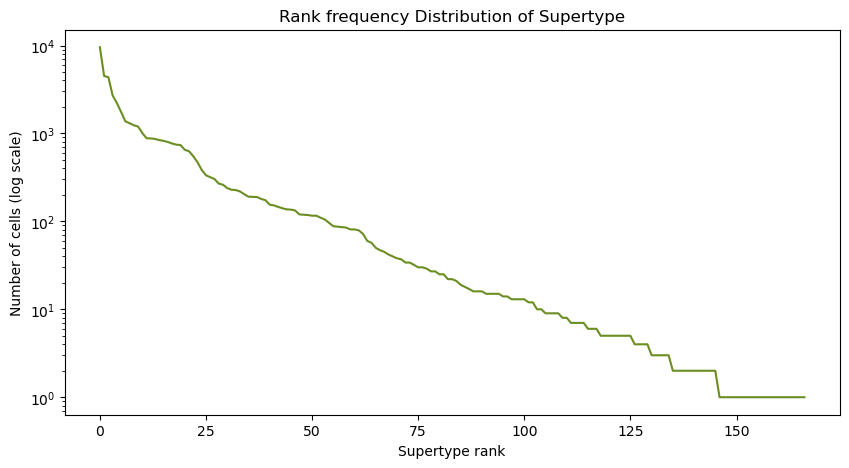

In [5]:
# Plot the distribution of supertypes
plt.figure(figsize=(10,5))

# Sort supertype counts in descending order and convert to rank-based index
supertype_counts.sort_values(ascending=False).reset_index(drop=True).plot(color="olivedrab")

# Use log scale because distribution is highly imbalanced
plt.yscale("log") 

plt.xlabel("Supertype rank")
plt.ylabel("Number of cells (log scale)")
plt.title("Rank frequency Distribution of Supertype")
plt.show()

### Spatial coordinates distribution

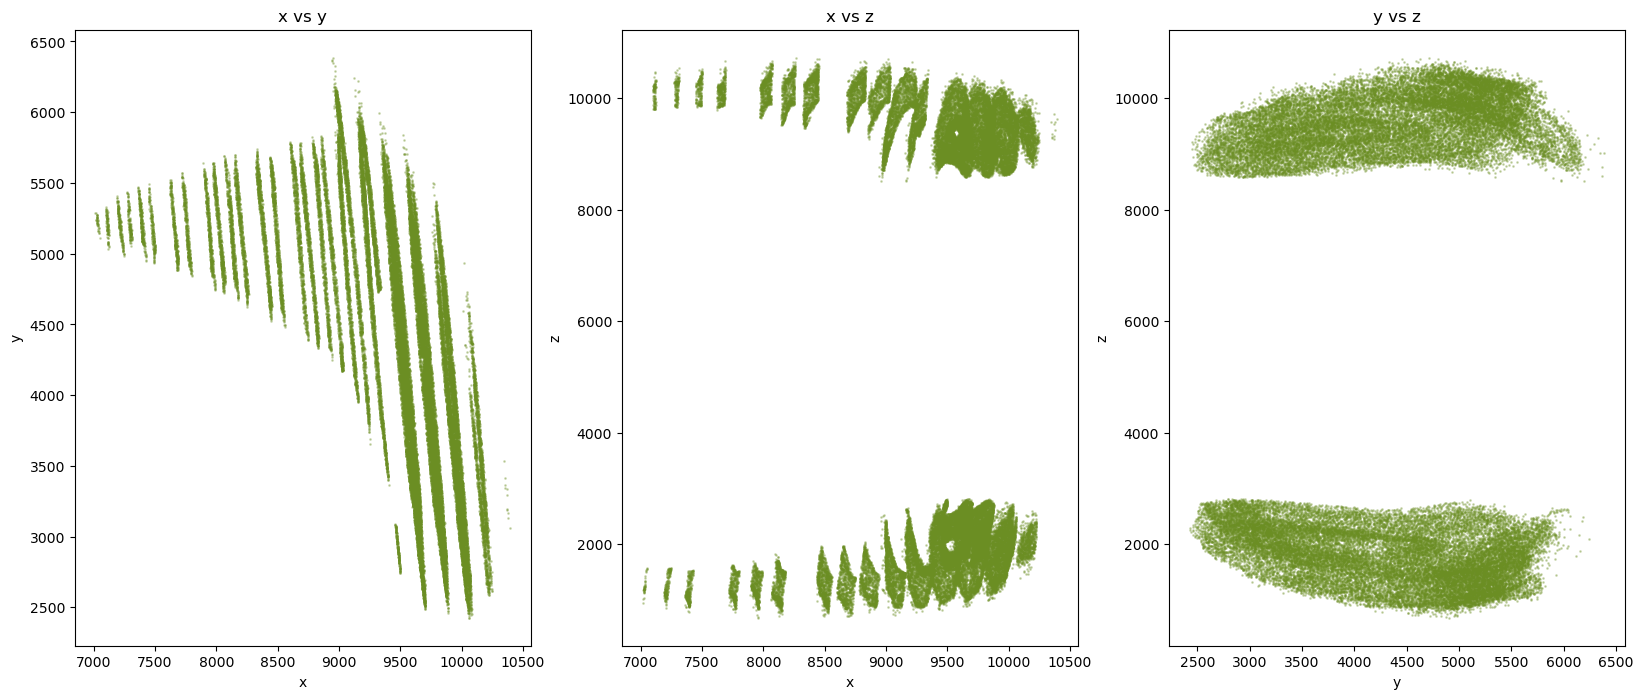

In [6]:
# plot the spatial coordinates distribution
fig, ax = plt.subplots(1,3,figsize=(20,8))

ax[0].scatter(cell_metadata["x_ccf"], cell_metadata["y_ccf"], s=1, alpha=0.3, color="olivedrab")
ax[0].set_title("x vs y")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")

ax[1].scatter(cell_metadata["x_ccf"], cell_metadata["z_ccf"], s=1, alpha=0.3, color="olivedrab")
ax[1].set_title("x vs z")
ax[1].set_xlabel("x")
ax[1].set_ylabel("z")

ax[2].scatter(cell_metadata["y_ccf"], cell_metadata["z_ccf"], s=1, alpha=0.3, color="olivedrab")
ax[2].set_title("y vs z")
ax[2].set_xlabel("y")
ax[2].set_ylabel("z") 

plt.show()

### Extract the spatial distributions of the ten most abundant neuronal supertypes

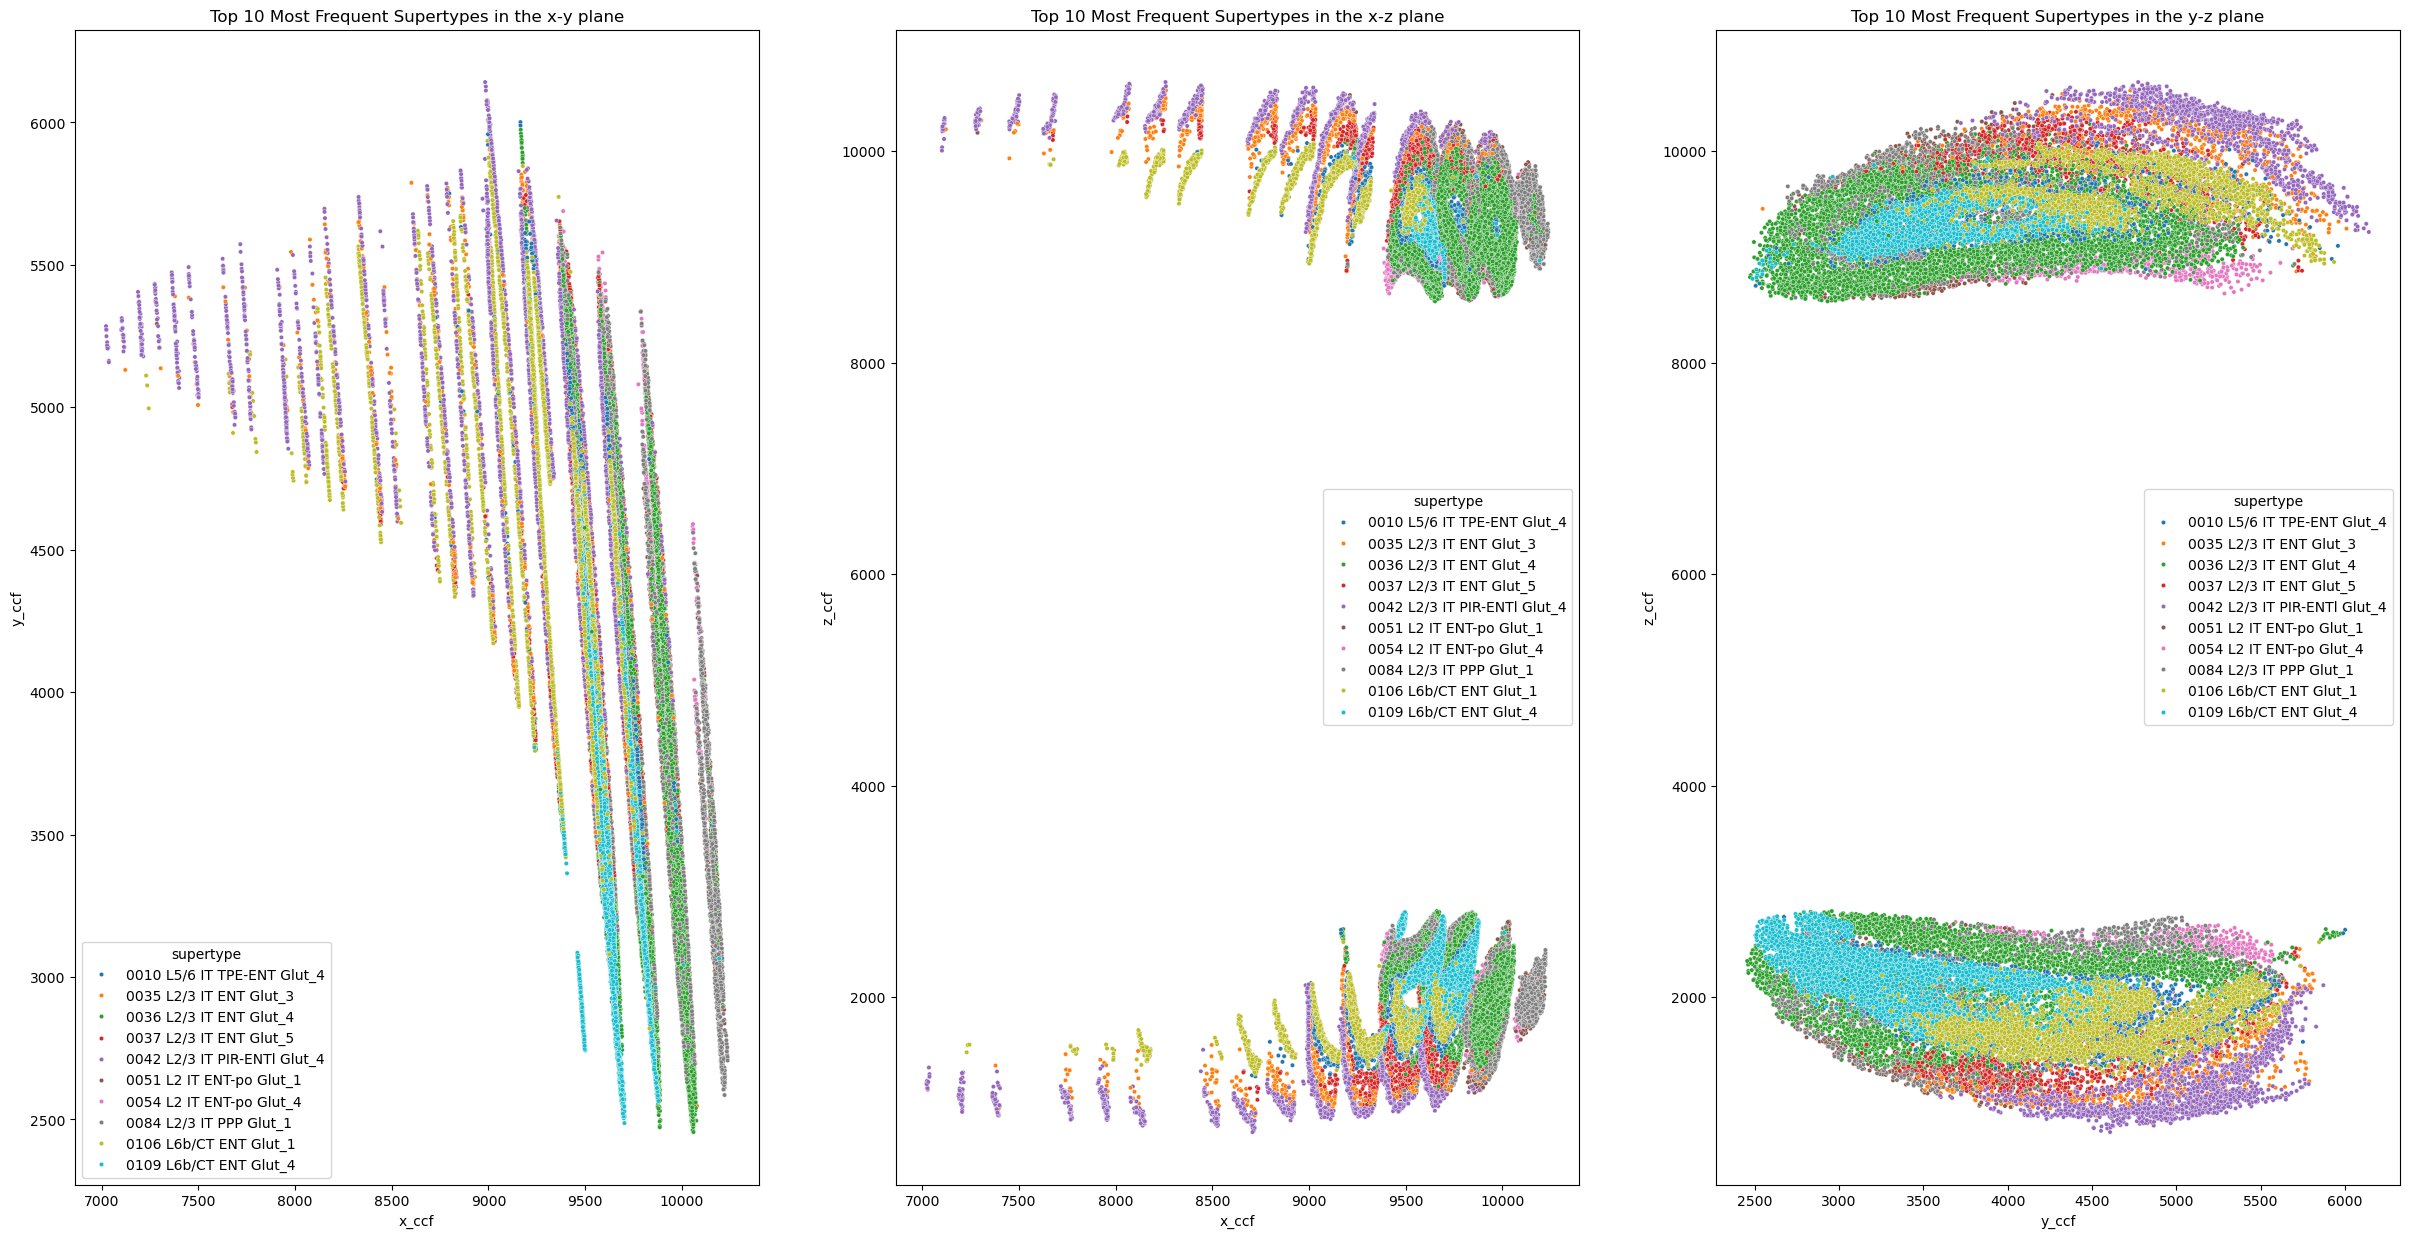

In [7]:
# Select top 10 most frequent supertypes
max10_supertype = supertype_counts.head(10).index

# Filter metadata to only include top 10 supertypes
max10_data = cell_metadata[cell_metadata["supertype"].isin(max10_supertype)]
max10_data = max10_data.copy()

# Remove unused categories after filtering
max10_data["supertype"] = max10_data["supertype"].cat.remove_unused_categories()

# plot 3-panel figure for 3D spatial visualization
fig, ax = plt.subplots(1,3,figsize=(30,15))

sns.scatterplot(data=max10_data,
                x="x_ccf",y="y_ccf",
                hue="supertype",
                s=10, ax=ax[0])
ax[0].set_title("Top 10 Most Frequent Supertypes in the x-y plane")
sns.scatterplot(data=max10_data,
                x="x_ccf",y="z_ccf",
                hue="supertype",
                s=10, ax=ax[1])
ax[1].set_title("Top 10 Most Frequent Supertypes in the x-z plane")
sns.scatterplot(data=max10_data,
                x="y_ccf",y="z_ccf",
                hue="supertype",
                s=10, ax=ax[2])
ax[2].set_title("Top 10 Most Frequent Supertypes in the y-z plane")
plt.show()


## Data Preprocessing

### Remove singleton sample supertypes

In [8]:
# Select supertypes that appear at least 2 times
supertypes_lager_than1 = supertype_counts[supertype_counts >= 2].index

# Filter metadata to keep only those selected supertypes
df = cell_metadata[cell_metadata["supertype"].isin(supertypes_lager_than1)].copy()

### Train/Test Split

In [9]:
# Define features (3D spatial coordinates) and target (supertype)
X, y = df[["x_ccf", "y_ccf", "z_ccf"]], df["supertype"]

# Split data into training and testing sets
# stratify=y ensures class distribution is preserved in both sets
X_train, X_test, y_train, y_test= train_test_split(
    X, y,
    stratify=y, 
    test_size=0.2, 
    random_state=0)

## Modal Fitting

### 1. Dummy Classifier 

In [10]:
# Dummy classifier baseline (always predicts the most frequent class)
# Used as a performance lower bound for comparison with real models
dm_st = DummyClassifier(strategy="most_frequent", random_state=0).fit(X_train, y_train)

# Predict class labels on test set
y_pred_dm_st = dm_st.predict(X_test)

# Predict class probabilities on test set
y_prob_dm_st = dm_st.predict_proba(X_test)

print("accuracy score:", accuracy_score(y_test, y_pred_dm_st))
print("balanced accuracy score:", balanced_accuracy_score(y_test, y_pred_dm_st))
print("macro f1 score:", f1_score(y_test, y_pred_dm_st, average="macro"))
print("top 5 accuracy score:", top_k_accuracy_score(y_test, y_prob_dm_st, k=5, labels=dm_st.classes_))

accuracy score: 0.19672805844222657
balanced accuracy score: 0.007407407407407408
macro f1 score: 0.002435381818066024
top 5 accuracy score: 0.19806564461364337


### 2. K-nearest Neighbours Classifier 

In [11]:
# k-Nearest Neighbors classifier (k=5)
# Classifies each point based on the majority label of its 5 nearest neighbors
kn_st = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)

# Predict class labels on test set
y_pred_kn_st = kn_st.predict(X_test)

# Predict class probabilities on test set
y_prob_kn_st = kn_st.predict_proba(X_test)

print("accuracy score:", accuracy_score(y_test, y_pred_kn_st))
print("balanced accuracy score:", balanced_accuracy_score(y_test, y_pred_kn_st))
print("macro f1 score:", f1_score(y_test, y_pred_kn_st, average="macro"))
print("top 5 accuracy score:", top_k_accuracy_score(y_test, y_prob_kn_st, k=5, labels=kn_st.classes_))

accuracy score: 0.5656960592653565
balanced accuracy score: 0.11418604964357838
macro f1 score: 0.106525107183454
top 5 accuracy score: 0.7322769832287273


c:\Users\ASUS\anaconda3\envs\mlpy\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


### 3. Random Forest Classifier 

In [12]:
# Random Forest classifier (500 trees)
rf_st = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced", # helps handle class imbalance by weighting classes inversely to frequency
    random_state=0
    ).fit(X_train, y_train)

# Predict class labels on test set
y_pred_rf_st = rf_st.predict(X_test)

# Predict class probabilities on test set
y_prob_rf_st = rf_st.predict_proba(X_test)

print("accuracy score:", accuracy_score(y_test, y_pred_rf_st))
print("balanced accuracy score:", balanced_accuracy_score(y_test, y_pred_rf_st))
print("macro f1 score:", f1_score(y_test, y_pred_rf_st, average="macro"))
print("top 5 accuracy score:", top_k_accuracy_score(y_test, y_prob_rf_st, k=5, labels=rf_st.classes_))


accuracy score: 0.5612717357752856
balanced accuracy score: 0.11381201646618926
macro f1 score: 0.11236197066838483
top 5 accuracy score: 0.797818705628151


## Result

In [13]:
# Generate classification report for Random Forest predictions
report = classification_report(y_test, y_pred_rf_st,
                               output_dict=True, # Returns a dictionary for easier post-processing
                               zero_division=0)

# Convert report dictionary into a DataFrame for analysis
report_df = pd.DataFrame(report).T

# Keep only per-class metrics
class_report = report_df[:-3].copy()

# Transform support using log scale to reduce extreme imbalance effects
class_report["support log"] = np.log1p(class_report["support"])

# Create a combined score balancing performance (F1) and class frequenc
class_report["score"] = class_report["f1-score"] * class_report["support log"]

# Sort classes by combined score
class_report = class_report.sort_values("score",ascending=False)

# Separate score = 0 classes
class_report_zero = class_report[class_report["score"] == 0].copy()

# Separate meaningful classes
class_report_nonzero = class_report[class_report["score"] > 0].copy()

# Best
# Top classes based on combined score
best = class_report_nonzero.sort_values(by="score", ascending=False).head(2).drop(columns=["support log"])

# Worst
# High support but completely misclassified classes
worst = class_report_zero.sort_values(by="support", ascending=False).head(2).drop(columns=["support log"])

# Middle
# Classes closest to F1 = 0.5
target_f1 = 0.5
middle = (
    class_report_nonzero
    .assign(dist_to_mid=(class_report_nonzero["f1-score"] - target_f1).abs())
    .sort_values(["dist_to_mid", "support"], ascending=[True, False])
    .head(2)
    .drop(columns=["dist_to_mid","support log"])
    .copy()
)


print("Worst Classes:")
print(worst)
print("Middle Classes:")
print(middle)
print("Best Classes:")
print(best)

Worst Classes:
                   precision  recall  f1-score  support  score
0207 Pvalb Gaba_3        0.0     0.0       0.0     61.0    0.0
0215 Sst Gaba_2          0.0     0.0       0.0     44.0    0.0
Middle Classes:
                         precision    recall  f1-score  support     score
0033 L2/3 IT ENT Glut_1   0.432331  0.569307  0.491453    202.0  2.611191
0084 L2/3 IT PPP Glut_1   0.466488  0.495726  0.480663    351.0  2.818430
Best Classes:
                         precision    recall  f1-score  support     score
0036 L2/3 IT ENT Glut_4   0.751073  0.915272  0.825083   1912.0  6.234677
0109 L6b/CT ENT Glut_4    0.733591  0.870561  0.796228    873.0  5.392919


In [14]:
# Extract index from selected performance groups
best_classes = best.index.tolist()
middle_classes = middle.index.tolist()
worst_classes = worst.index.tolist()

In [15]:
# Create mapping to performance group
class_to_group = {}

# Assign "Best" group
for cls in best_classes:
    class_to_group[cls] = "Best"

# Assign "Middle" group
for cls in middle_classes:
    class_to_group[cls] = "Middle"

# Assign "Worst" group
for cls in worst_classes:
    class_to_group[cls] = "Worst"

In [16]:
# Filter dataframe to only include classes that were assigned a performance group
plot_df = df[df["supertype"].isin(class_to_group)].copy()

# Map each supertype to its performance category
plot_df["performance_group"] = plot_df["supertype"].map(class_to_group)

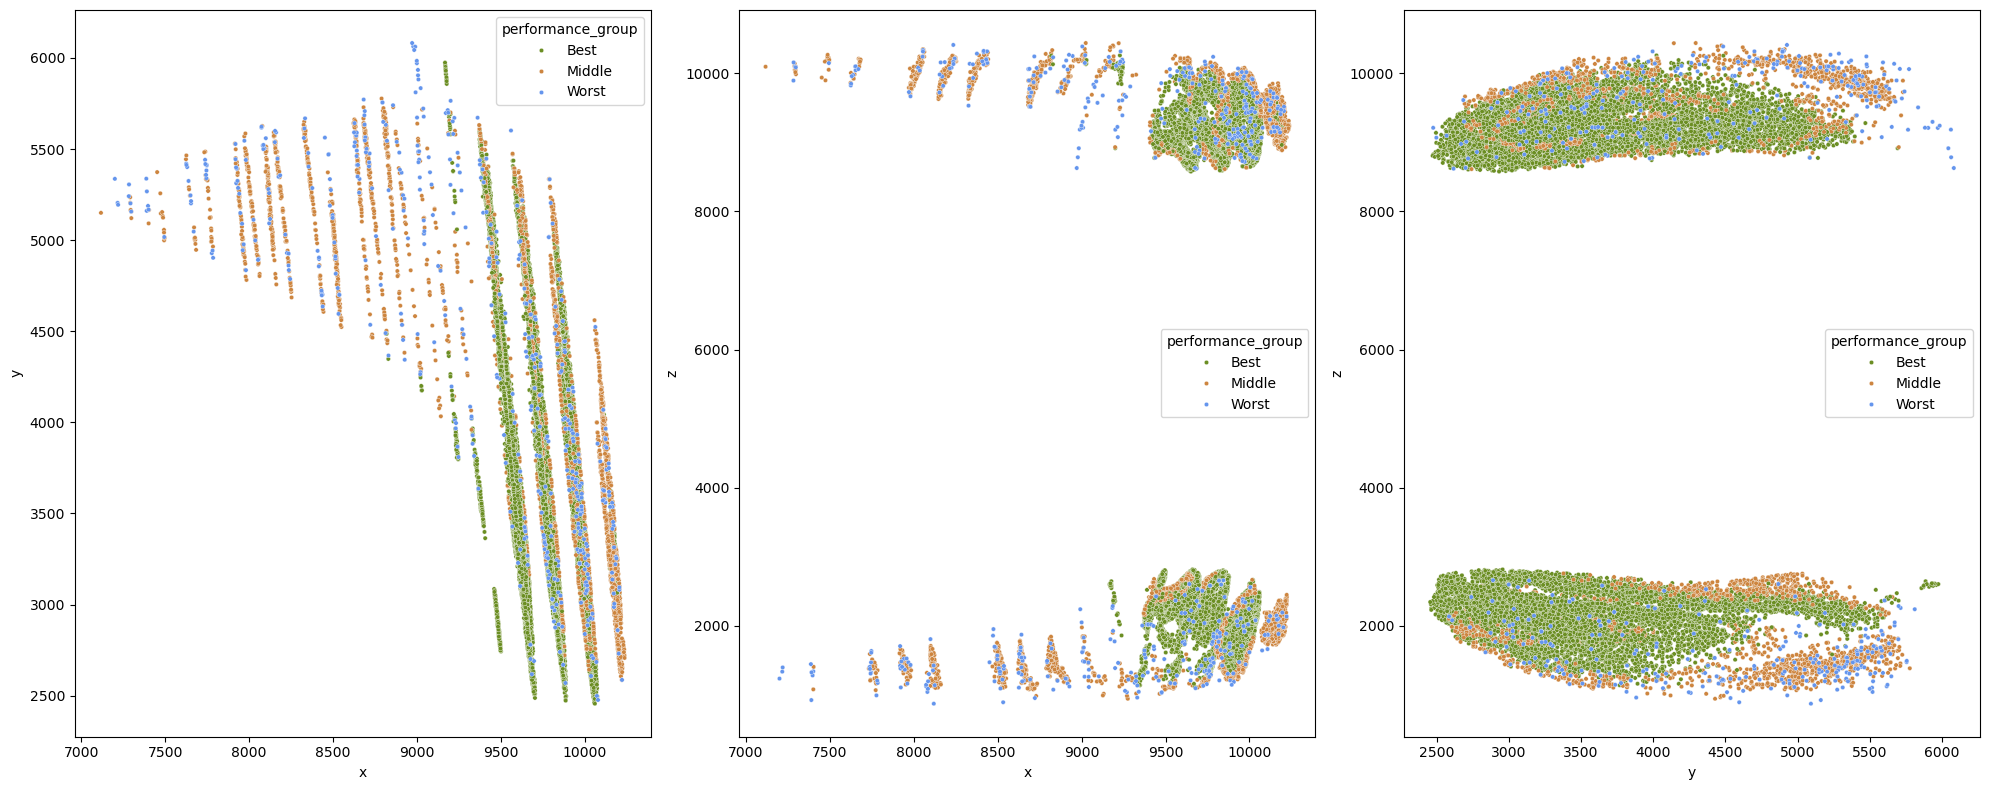

In [17]:
# Plot 3-panel figure for spatial comparison across different planes
fig, ax = plt.subplots(1, 3, figsize=(20, 8))

palette = {
    "Best":"olivedrab",
    "Middle":"peru",
    "Worst":"cornflowerblue"
}

sns.scatterplot(data=plot_df,
                x="x_ccf", y="y_ccf",
                hue="performance_group",
                palette=palette,
                s=10, ax=ax[0])

ax[0].set_xlabel("x")
ax[0].set_ylabel("y")

sns.scatterplot(data=plot_df,
                x="x_ccf", y="z_ccf",
                hue="performance_group",
                palette=palette,
                s=10, ax=ax[1])

ax[1].set_xlabel("x")
ax[1].set_ylabel("z")

sns.scatterplot(data=plot_df,
                x="y_ccf", y="z_ccf",
                hue="performance_group",
                palette=palette,
                s=10, ax=ax[2])

ax[2].set_xlabel("y")
ax[2].set_ylabel("z")

plt.tight_layout()
plt.show()